# 04 — Fine-tuning data: download, format & analysis

This notebook prepares and documents **everything YourMT3+ needs for fine-tuning**:

1. **Download** the reference datasets (EGMD, MAESTRO, Slakh) into Google Drive — *idempotent*: anything already in Drive is skipped.
2. **Explain the data format** YourMT3+ expects, and show it live on a real example.
3. **Analyze** what is in Drive: sizes, hours, splits, instrument categories.
4. Document **what YourMT3+ was originally trained on** and **its augmentation strategy** (grounded in the actual training code).
5. Verify our **Strudel data** (corpus + synthetic-inspired) is in the same format — it is *generated on a local machine* (needs Node + the corpus submodules) and pushed to Drive with `scripts/dataset/sync_drive.sh push`.
6. Enforce a **clean train / validation / test / holdout separation** with hard checks.

> **Drive space warning** — full archive sizes (verified): **EGMD ≈ 36 GB**, **MAESTRO ≈ 19 GB**, Slakh ≈ 30 GB.
> A free Google account has 15 GB. Enable only what fits (config cell below); MAESTRO is the cheapest
> pitched-note replay set, EGMD the closest to our domain but also the largest.
> Colab scratch disk note: extraction needs ~2× the archive size free on `/content`
> (EGMD peaks around 72 GB) — use a runtime with enough disk, one set at a time. You can also fine-tune with a *subset* — the sampling weights
> in training control the mix, not the raw sizes.

In [1]:
# Environment: Colab (Drive-mounted) or local checkout.
import json, os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/restrudel")
    DATA_HOME = DRIVE / "datasets"           # durable store (same layout sync_drive.sh pushes to)
    SCRATCH = Path("/content/scratch")       # fast ephemeral disk for download+extract
    if not Path("/content/restrudel").exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/henrik253/Restrudel.git", "/content/restrudel"], check=True)
    REPO = Path("/content/restrudel")
    # Installer deps found by tracing install_dataset's import chain; mirdata is
    # pinned: 0.3.9+ removed jams_utils which their slakh16k loader imports.
    %pip -q install huggingface_hub mido "mirdata==0.3.8" pretty_midi mir_eval torchmetrics deprecated smart_open
else:
    REPO = Path(os.environ.get("RESTRUDEL_REPO", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
    DATA_HOME = Path(os.environ.get("RESTRUDEL_DATA_HOME", REPO / "datasets"))
    SCRATCH = DATA_HOME  # locally, download straight into place

SCRATCH.mkdir(parents=True, exist_ok=True)
DATA_HOME.mkdir(parents=True, exist_ok=True)
INDEX_DIR = DATA_HOME / "yourmt3_indexes"
print(f"colab={IN_COLAB}\nrepo={REPO}\ndata_home={DATA_HOME}")

colab=False
repo=/Users/henrik/Documents/Informatik/Master/restrudel/.claude/worktrees/strudel-split-policy
data_home=/Users/henrik/Documents/Informatik/Master/restrudel/datasets


In [2]:
# ---- config: which reference sets to download this run --------------------
# Idempotent: a set whose index files already exist in DATA_HOME is skipped.
DOWNLOAD = {
    "egmd": False,     # ~22 GB — electronic drums (closest to our domain)
    "maestro": False,  # ~19 GB — piano; cheap, high-quality pitched replay data
    "slakh": False,    # ~30 GB — multi-track band mixes; the main forgetting-mitigation set
}

## 1. The format YourMT3+ expects

YourMT3+'s training code does **not** read raw (WAV, MIDI) pairs. Every dataset is converted
once into this layout (all paths below live under `DATA_HOME`):

```
<dataset>_yourmt3_16k/<song>/
    mix.wav                  16 kHz, MONO, 16-bit PCM  ← the model frontend's native format
    <song>_notes.npy         pickled dict {..., 'notes': [Note, ...]}
    <song>_note_events.npy   pickled dict {..., 'note_events': [NoteEvent, ...]}
    <song>.mid               the labels as MIDI (human-listenable, not used by the loader)
yourmt3_indexes/
    <dataset>_train_file_list.json        ← what the data loader actually opens
    <dataset>_validation_file_list.json
    <dataset>_test_file_list.json
```

The two dataclasses (from `amt/src/utils/note_event_dataclasses.py`):

| `Note` field | meaning |
|---|---|
| `is_drum` | drum-channel note (no offset semantics) |
| `program` | GM program 0–127, or 128 for drums |
| `onset` / `offset` | **seconds** (float), not ticks |
| `pitch` | MIDI pitch 0–127 (for drums: GM percussion number) |
| `velocity` | binary (1) for synthetic data |

`NoteEvent` is the same information flattened into an onset/offset event stream — that is
what gets tokenized into the model's output sequence. The tokenizer segments audio into
~2.048 s crops and emits event tokens per segment.

**Who is already in shape?**

| source | in shape? | how |
|---|---|---|
| EGMD / MAESTRO / Slakh (Zenodo/mirdata archives) | ✅ yes | YourMT3 hosts *preprocessed 16 kHz* versions; `install_dataset.py` just unpacks + indexes them |
| our Strudel data (corpus + inspired) | ✅ yes | `scripts/dataset/preprocess_strudel.py` renders 16 kHz mono WAV + converts queryArc labels into `Note`/`NoteEvent` (tokenizer-verified, ±0.3 ms alignment) |
| Lakh MIDI (electronic subset) | ⚠️ labels only | `scripts/dataset/prepare_lakh.py` builds the `.npy` labels; **audio must be synthesized** (MIDI-only dataset) — placeholder synth now, real synth renders (Surge/Vital) later |

So yes — the working unit is exactly your guess (**audio in, MIDI-like events out**), plus
the index JSONs that glue them together.

In [3]:
# YourMT3's code (amt/src) is needed to unpickle Note/NoteEvent and to run installers.
# Code-only fetch (~few MB) — the 536 MB checkpoint is NOT needed for data work.
AMT_SRC = Path(os.environ.get("RESTRUDEL_AMT_SRC", REPO / "models" / "YourMT3" / "amt" / "src"))
if not AMT_SRC.exists():
    from huggingface_hub import snapshot_download
    snapshot_download(repo_id="mimbres/YourMT3", repo_type="space",
                      allow_patterns=["amt/src/**"], local_dir=AMT_SRC.parents[1])
sys.path.insert(0, str(AMT_SRC))
print("amt/src:", AMT_SRC)

amt/src: /Users/henrik/Documents/Informatik/Master/restrudel/models/YourMT3/amt/src


In [4]:
# Format demo on a real song (first Strudel song found in Drive/DATA_HOME).
import numpy as np, wave

demo = sorted((DATA_HOME / "strudel_yourmt3_16k").glob("*/")) if (DATA_HOME / "strudel_yourmt3_16k").exists() else []
if not demo:
    print("no Strudel data in DATA_HOME yet — run preprocess_strudel.py locally and sync_drive.sh push")
else:
    d = demo[0]; sid = d.name
    notes = np.load(d / f"{sid}_notes.npy", allow_pickle=True).item()
    nev = np.load(d / f"{sid}_note_events.npy", allow_pickle=True).item()
    with wave.open(str(d / "mix.wav")) as w:
        print(f"{sid}: mix.wav {w.getframerate()} Hz, {w.getnchannels()} ch, {w.getnframes()/w.getframerate():.1f} s")
    print("programs:", notes["program"], " is_drum:", notes["is_drum"], " duration:", notes["duration_sec"], "s")
    print("first 3 Notes:      ", *notes["notes"][:3], sep="\n  ")
    print("first 3 NoteEvents: ", *nev["note_events"][:3], sep="\n  ")
    fl = json.load(open(INDEX_DIR / "strudel_train_file_list.json"))
    print("\nindex entry 0:", json.dumps(fl["0"], indent=2)[:500])

corpus_0002bbc4d6: mix.wav 16000 Hz, 1 ch, 18.0 s
programs: [128]  is_drum: [1]  duration: 16 s
first 3 Notes:      
  Note(is_drum=True, program=128, onset=0, offset=0.01, pitch=36, velocity=1)
  Note(is_drum=True, program=128, onset=0, offset=0.01, pitch=42, velocity=1)
  Note(is_drum=True, program=128, onset=0.333333, offset=0.343333, pitch=42, velocity=1)
first 3 NoteEvents: 
  NoteEvent(is_drum=True, program=128, time=0, velocity=1, pitch=36, activity=set())
  NoteEvent(is_drum=True, program=128, time=0, velocity=1, pitch=42, activity=set())
  NoteEvent(is_drum=True, program=128, time=0.333333, velocity=1, pitch=42, activity=set())

index entry 0: {
  "strudel_id": "corpus_5bd2ab7e90",
  "n_frames": 288000,
  "mix_audio_file": "/Users/henrik/Documents/Informatik/Master/restrudel/datasets/strudel_yourmt3_16k/corpus_5bd2ab7e90/mix.wav",
  "notes_file": "/Users/henrik/Documents/Informatik/Master/restrudel/datasets/strudel_yourmt3_16k/corpus_5bd2ab7e90/corpus_5bd2ab7e90_notes.npy",
  

## 2. Download the reference datasets → Drive

These are the **forgetting-mitigation** sets: fine-tuning only on Strudel/synth data would
degrade the model on everything else, so training batches mix ~20–50 % of the original data
back in. YourMT3 hosts *already-preprocessed* 16 kHz archives (Zenodo; Slakh via `mirdata`) —
the cell below downloads + extracts to fast local scratch, runs their own indexer, then moves
the result into Drive. **Re-runs skip anything already present.**

On Colab this avoids extracting tarballs directly onto the Drive mount (slow/flaky);
the durable copy still ends up in Drive.

In [5]:
def dataset_present(name: str) -> bool:
    return any(INDEX_DIR.glob(f"{name}*_file_list.json"))

def move_into_drive(src_home: Path, name_hints: list):
    """Move freshly built dataset dirs + index files from scratch into DATA_HOME."""
    if src_home == DATA_HOME:
        return
    for p in src_home.iterdir():
        if p.name == "yourmt3_indexes":
            INDEX_DIR.mkdir(exist_ok=True)
            for f in p.iterdir():
                shutil.move(str(f), INDEX_DIR / f.name)
        elif any(h in p.name for h in name_hints):
            shutil.move(str(p), DATA_HOME / p.name)

for name, enabled in DOWNLOAD.items():
    if not enabled:
        print(f"[skip] {name}: disabled in config"); continue
    if dataset_present(name):
        print(f"[skip] {name}: index files already in {INDEX_DIR}"); continue
    print(f"[download] {name} -> scratch={SCRATCH} ...")
    # Stream the installer's output into the cell — in Colab, child-process
    # stdout/stderr bypasses the notebook entirely, so a plain run() hides errors.
    p = subprocess.Popen([sys.executable, str(REPO / "scripts" / "dataset" / "install_reference_sets.py"),
                          "--sets", name, "--data-home", str(SCRATCH), "--amt-src", str(AMT_SRC)],
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in p.stdout:
        tail.append(line); tail = tail[-30:]
        if len(tail) % 10 == 1 or "===" in line or "Error" in line:
            print(line, end="")
    if p.wait() != 0:
        print(f"[FAIL] {name} — last lines:\n" + "".join(tail)); continue
    move_into_drive(SCRATCH, [name])
    print(f"[done] {name}")

# Index paths were written for the machine that built them; rewrite to this DATA_HOME.
for fl_path in INDEX_DIR.glob("*_file_list.json"):
    fl = json.load(open(fl_path)); changed = False
    for e in fl.values():
        for k in ("mix_audio_file", "notes_file", "note_events_file", "midi_file", "stem_file"):
            if k in e and e[k]:
                tail = e[k].split("/datasets/")[-1] if "/datasets/" in e[k] else None
                new = str(DATA_HOME / tail) if tail else e[k]
                if new != e[k]: e[k] = new; changed = True
    if changed:
        json.dump(fl, open(fl_path, "w"), indent=4); print("rewrote paths:", fl_path.name)

[skip] egmd: disabled in config
[skip] maestro: disabled in config
[skip] slakh: disabled in config


## 3. What's in the store — sizes, splits, categories

In [6]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def hours(fl): return sum(e.get("n_frames", 0) for e in fl.values()) / 16000 / 3600

rows, prog_hist = [], defaultdict(Counter)
for fl_path in sorted(INDEX_DIR.glob("*_file_list.json")):
    ds, _, split = fl_path.stem.replace("_file_list", "").rpartition("_")
    fl = json.load(open(fl_path))
    rows.append((ds, split, len(fl), round(hours(fl), 2)))
    for e in fl.values():
        for p, isd in zip(e.get("program", []), e.get("is_drum", [])):
            prog_hist[ds]["drums" if (isd or p == 128) else f"prog {p}"] += 1

print(f"{'dataset':<12} {'split':<12} {'songs':>7} {'hours':>8}")
for ds, split, n, h in rows:
    print(f"{ds:<12} {split:<12} {n:>7} {h:>8}")

sizes = {p.name: sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1e9
         for p in DATA_HOME.iterdir() if p.is_dir() and p.name != "yourmt3_indexes"}
print("\ndisk usage (GB):", {k: round(v, 2) for k, v in sorted(sizes.items())})

dataset      split          songs    hours
strudel      test               0      0.0
strudel      train            753     3.71
strudel      validation        32     0.16

disk usage (GB): {'strudel_yourmt3_16k': 0.49}


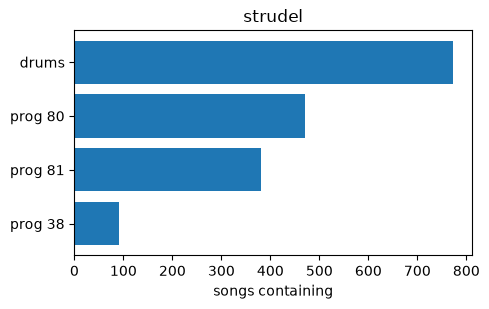

In [7]:
# Instrument-category view per dataset (top categories by song-level presence)
n = len(prog_hist)
if n:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.2), squeeze=False)
    for ax, (ds, cnt) in zip(axes[0], sorted(prog_hist.items())):
        top = cnt.most_common(10)
        ax.barh([k for k, _ in top][::-1], [v for _, v in top][::-1])
        ax.set_title(ds); ax.set_xlabel("songs containing")
    plt.tight_layout(); plt.show()
else:
    print("nothing indexed yet")

## 4. What YourMT3+ itself was trained on

The checkpoint we fine-tune (`...all_v7...nops`, i.e. the *noPS* YPTF.MoE+Multi variant)
was trained with the **`all_cross_final`** preset (`amt/src/config/data_presets.py`) —
10 datasets sampled with these weights:

| dataset | weight | role |
|---|---|---|
| Slakh2100 (`slakh_final`) | 0.295 | multi-instrument band mixes (sample-library renders) |
| MIR-ST500 vocals | 0.191 | singing voice |
| MusicNet (EM labels) | 0.190 | classical chamber/orchestral |
| URMP | 0.100 | classical ensembles |
| MAESTRO | 0.100 | piano |
| ENST-drums (DTP) | 0.050 | acoustic drum kit |
| CMedia vocals | 0.050 | singing voice |
| GuitarSet (progressions, pitch-shifted) | 0.010 | acoustic guitar |
| IDMT-SMT-bass | 0.010 | bass guitar |
| **EGMD** | **0.004** | electronic drum kit |

Two things to notice for our purposes:

1. **Nothing in this list contains subtractive/FM/wavetable synth timbres.** Slakh is MIDI
   rendered through *sampled acoustic instruments*; that is precisely the gap Restrudel's
   Strudel-rendered data fills — and why the stock model scores so poorly on synth-heavy
   electronic music.
2. Evaluation used a separate `all_eval_final` preset with per-dataset instrument
   vocabularies and a kick/snare/hihat drum metric — a template for how we should define a
   `strudel_eval` preset later.

### Their augmentation strategy (`amt/src/utils/augment.py`)

Augmentation happens **on-the-fly at the stem level** inside each ~2 s training crop:

- **Intra-stem augmentation** (`intra_stem_augment_processor`): within one song, randomly
  *drop stems* (`drop_random_stems_from_bundle`, p≈0.7) and re-mix the survivors with random
  gains (`audio_random_submix_fn`) — the model sees many sub-mixes of the same bar.
- **Cross-dataset stem mixing** (`cross_stem_augment_processor`): stems from *different
  songs/datasets* are combined into synthetic mixtures (e.g. EGMD drums under MAESTRO piano).
  How many sources get stacked is sampled from a survival function
  (`combined_survival_and_stop`, max ≈ 5, τ≈0.3), and instrument collisions are resolved by
  regrouping shared program subunits (`regroup_program_and_audio_by_minimal_shared_subunits`).
- **Pitch shift**: the general recipe supports ±2 semitone shifts, but our checkpoint is the
  **noPS** (no pitch shift) variant — GuitarSet was pre-shifted offline instead.

**Consequence for our data**: the loaders only unlock the full augmentation when a song has a
`stem_file`. Our current Strudel builds are single-mix (no stems yet) — they still train fine,
but rendering each `$:` voice separately is the highest-leverage upgrade on the roadmap, and
Strudel makes it trivial (each voice is already a separate pattern).

In [8]:
# Ground the augmentation summary in the actual code: list the processors.
import inspect
import utils.augment as aug
for fname in ["intra_stem_augment_processor", "drop_random_stems_from_bundle",
              "audio_random_submix_fn", "cross_stem_augment_processor",
              "combined_survival_and_stop"]:
    fn = getattr(aug, fname)
    doc = (inspect.getdoc(fn) or "").splitlines()
    print(f"- {fname}{inspect.signature(fn)}")
    if doc: print(f"    {doc[0]}")

/Users/henrik/Documents/Informatik/Master/restrudel/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- intra_stem_augment_processor(sampled_data: Dict[str, Any], random_amp_range: List[float] = [0.6, 1.2], prob: float = 0.7, update_audio_segments: bool = True, submix_audio: bool = True) -> None
    Intra_stem_augmentation
- drop_random_stems_from_bundle(sampled_data: Dict[str, Any], prob: float = 0.7) -> None
    Drop stems with a probability of `prob` from a bundle containing `note_event_segments` and 
- audio_random_submix_fn(x: numpy.ndarray, random_amp_range: Optional[List[float]] = None, mask: Optional[numpy.ndarray] = None, normalize: bool = True, dtype: numpy.dtype = <class 'numpy.float32'>) -> Tuple[numpy.ndarray, numpy.ndarray]
    Randomly submix audio. This function supports batch-wise matrix processing.
- cross_stem_augment_processor(sampled_data: Dict[str, Any], sampled_ids: numpy.ndarray, get_rand_segments_from_cache_fn: Callable, random_amp_range: List[float] = [0.6, 1.2], stem_iaug_prob: float = 0.7, stem_xaug_policy: Dict = {'max_k': 3, 'tau': 0.3, 'alpha': 1.0, 'max_

## 5. Our Strudel data (corpus 50 % + synthetic-inspired)

Generated **on the local machine** (needs Node, `data_gen/` and the corpus git submodules —
not practical on Colab) and pushed here with:

```bash
.venv/bin/python scripts/dataset/preprocess_strudel.py   # build (≈900 songs)
scripts/dataset/sync_drive.sh push                       # -> Drive
```

What the builder guarantees (details: `scripts/dataset/README.md`):

- **Sources**: 50 % of the 855 corpus snippets (deterministic hash split — the other half is
  *never rendered*, recorded in `strudel_holdout.json`) + all 500 *inspired* songs
  (`dataset/generated_500_inspired.yaml`). The raw sampled sketches are **not** used.
- Audio and labels come from **one shared evaluation code path** (`data_gen/strudel_eval.mjs`),
  so they cannot drift — measured onset alignment ≈ +0.3 ms.
- Programs map into the checkpoint's vocabulary buckets (synth leads → 80/81, sub-C3 voices →
  synth bass 38, `cp` → 40 because the GM drum vocab has **no clap class**).
- Every song passes the real Strudel engine (queryArc) and YourMT3's tokenizer round-trip.

In [9]:
# Verify the Strudel data present here matches expectations.
ok = True
sd = DATA_HOME / "strudel_yourmt3_16k"
if not sd.exists():
    print("Strudel data not in Drive yet — push it from the local machine."); ok = False
else:
    per_split = {s: json.load(open(INDEX_DIR / f"strudel_{s}_file_list.json"))
                 for s in ("train", "validation", "test")}
    n = {s: len(fl) for s, fl in per_split.items()}
    hrs = {s: round(hours(fl), 2) for s, fl in per_split.items()}
    print("songs per split:", n, " hours:", hrs)
    rep = DATA_HOME / "strudel_build_report.json"
    if rep.exists():
        r = json.load(open(rep))
        print("build report: eval_fail:", len(r.get("failed_eval", [])),
              "render_fail:", len(r.get("failed_render", [])),
              "unknown sounds:", r.get("unknown_sounds", []))

songs per split: {'train': 753, 'validation': 32, 'test': 0}  hours: {'train': 3.71, 'validation': 0.16, 'test': 0.0}
build report: eval_fail: 0 render_fail: 0 unknown sounds: []


## 6. Train / validation / test / holdout — the rules

These rules are **load-bearing**; every later step (fine-tuning, evaluation, the thesis
numbers) depends on them not eroding:

1. **Corpus holdout (50 %)** — chosen by a deterministic hash of the code, recorded in
   `strudel_holdout.json`, **never rendered into training data**. This is the *only* fully
   independent human-written Strudel eval set we will ever have — nothing from it (not even
   for "just a quick look" during training) may enter any training or validation index.
2. **Strudel data is train/validation ONLY (95/5, hash-derived → stable across rebuilds).**
   Neither corpus-derived nor synthetic-inspired songs ever enter a test split: testing on
   self-made synthetic data would flatter the numbers. Tests use (i) the reference sets'
   canonical test splits, (ii) the corpus holdout, (iii) real recordings.
3. **Reference sets keep their canonical splits** (Slakh/MAESTRO/EGMD ship official
   train/validation/test) — we never re-split them, so our numbers stay comparable to
   published results.
4. **Inspired-song provenance**: inspired songs derive from corpus patterns, so any inspired
   song identical to a holdout snippet would leak. The check below verifies this too.
5. **Real recordings** (`mp3s/`) stay out of training entirely — reserved as a qualitative
   eval set for the full pipeline.

The cell below enforces 1–4 mechanically and fails loudly on violation.

In [10]:
# ---- split integrity checks (fail loudly) ---------------------------------
import hashlib, re
violations = []

def ids_of(fl, key_hint):
    return {next((v for k, v in e.items() if k.endswith("_id")), None) for e in fl.values()}

# (a) within each dataset: split disjointness
by_ds = defaultdict(dict)
for fl_path in INDEX_DIR.glob("*_file_list.json"):
    ds, _, split = fl_path.stem.replace("_file_list", "").rpartition("_")
    by_ds[ds][split] = json.load(open(fl_path))
for ds, splits in by_ds.items():
    names = sorted(splits)
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            inter = (ids_of(splits[a], ds) & ids_of(splits[b], ds)) - {None}
            if inter:
                violations.append(f"{ds}: {a} ∩ {b} = {len(inter)} songs")

# (a2) strudel is train/validation ONLY — test index must be empty
if "strudel" in by_ds and len(by_ds["strudel"].get("test", {})):
    violations.append(f"strudel test split must be EMPTY, has {len(by_ds['strudel']['test'])} songs")

# (b) corpus holdout never appears in any strudel index
hold_path = DATA_HOME / "strudel_holdout.json"
if hold_path.exists() and "strudel" in by_ds:
    holdout_ids = {h["id"] for h in json.load(open(hold_path))["holdout"]}
    trained_ids = set().union(*(ids_of(fl, "strudel") for fl in by_ds["strudel"].values())) - {None}
    leak = holdout_ids & trained_ids
    if leak:
        violations.append(f"HOLDOUT LEAK: {len(leak)} corpus snippets in training indexes")
    print(f"holdout: {len(holdout_ids)} snippets withheld; overlap with indexes: {len(leak)}")

# (c) inspired songs must not derive from holdout snippets
insp_yaml = REPO / "dataset" / "generated_500_inspired.yaml"
if hold_path.exists() and insp_yaml.exists():
    try:
        import yaml
    except ImportError:
        %pip -q install pyyaml
        import yaml
    doc = yaml.safe_load(open(insp_yaml))
    hold_hashes = {h["hash"] for h in json.load(open(hold_path))["holdout"]}
    derived = {s["id"]: hashlib.md5(re.sub(r"\s+", "", s["code"]).encode()).hexdigest()
               for s in doc["songs"]}
    leak = {i for i, h in derived.items() if h in hold_hashes}
    if leak:
        violations.append(f"inspired-from-holdout leak: {sorted(leak)[:5]} ...")
    print(f"inspired provenance check: {len(leak)} songs identical to holdout snippets")

if violations:
    raise AssertionError("SPLIT VIOLATIONS:\n  " + "\n  ".join(violations))
print("\nALL SPLIT CHECKS PASSED ✔")

holdout: 433 snippets withheld; overlap with indexes: 0


inspired provenance check: 0 songs identical to holdout snippets

ALL SPLIT CHECKS PASSED ✔


---
### Where this leaves us

- Drive holds every dataset in **one uniform, loader-ready format** with verified splits.
- Missing before a training run: per-voice **stems** for the Strudel data (unlock their
  augmentation), **real synth audio for Lakh**, and a `strudel` entry in
  `amt/src/config/data_presets.py` with sampling weights (+ a `strudel_eval` preset built
  from the corpus holdout).
